# Transforming Shapes with Matrices

## Purpose

Apply matrix transformations to many points at once.

So far, we have transformed individual vectors and basis directions.

A shape can be represented as a collection of points. If we transform each point, we transform the whole shape.

The new idea in this notebook is:

> transform every point, and the whole shape follows.

## Helpers

These helpers keep the plotting code out of the main examples.

In [1]:
import numpy as np
import matplotlib.pyplot as plt


def setup_shape_plot(title, xlim=(-5, 5), ylim=(-5, 5), figsize=(5, 5)):
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.3)
    ax.axhline(0, linewidth=1)
    ax.axvline(0, linewidth=1)
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    return fig, ax


def plot_shape(ax, points, label, linewidth=2, linestyle="-", alpha=1.0, marker="o"):
    points = np.array(points, dtype=float)
    closed_points = np.vstack([points, points[0]])

    ax.plot(
        closed_points[:, 0],
        closed_points[:, 1],
        marker=marker,
        linewidth=linewidth,
        linestyle=linestyle,
        alpha=alpha,
        label=label,
    )


def transform_points(matrix, points):
    points = np.array(points, dtype=float)
    matrix = np.array(matrix, dtype=float)
    return points @ matrix.T


def rotation_matrix_degrees(degrees):
    theta = np.deg2rad(degrees)
    return np.array([
        [np.cos(theta), -np.sin(theta)],
        [np.sin(theta),  np.cos(theta)],
    ])

## Representing a shape as points

Here is a simple square represented by its corner points:

$$
(0, 0), (1, 0), (1, 1), (0, 1)
$$

Each corner point can be treated like a small position vector from the origin.

In [2]:
square = np.array([
    [0, 0],
    [1, 0],
    [1, 1],
    [0, 1],
])

print(square)

[[0 0]
 [1 0]
 [1 1]
 [0 1]]


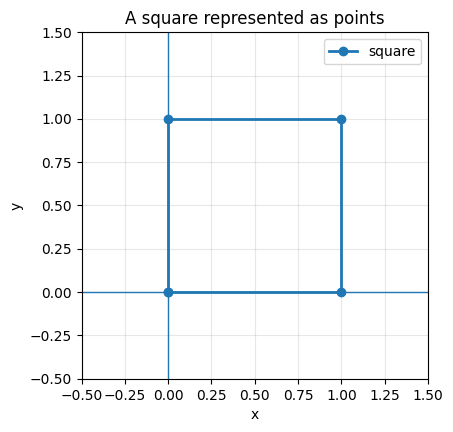

In [3]:
fig, ax = setup_shape_plot(
    "A square represented as points",
    xlim=(-0.5, 1.5),
    ylim=(-0.5, 1.5),
    figsize=(4.5, 4.5),
)

plot_shape(ax, square, label="square")
ax.legend()
plt.show()

The array has shape `(4, 2)`: four points, each with two coordinates.

In [4]:
square.shape

(4, 2)

## Applying one matrix to many points

In the previous matrix notebooks, the conceptual model was column-vector multiplication:

$$
\mathbf{v}' = A\mathbf{v}
$$

Now let $P$ be the collection of points that make up the shape.

Conceptually, the same idea is:

$$
P' = A(P)
$$

Read that as: apply matrix $A$ to every point in $P$.

In this notebook, $P$ is stored as a NumPy array with one point per row.

So the row-oriented NumPy version is:

$$
P' = PA^{\mathsf{T}}
$$

In code, that is:

```python
points @ matrix.T
```

This is not a new mathematical idea. It is just the same transformation written for the way our points are stored in the NumPy array.

The useful mental model remains simple: transform every point, and the whole shape follows.


## Scaling a shape

Use a scaling matrix:

$$
S =
\begin{bmatrix}
2 & 0 \\
0 & 1
\end{bmatrix}
$$

This doubles $x$-values and leaves $y$-values unchanged.


In [5]:
scale_x = np.array([
    [2, 0],
    [0, 1],
])

scaled_square = transform_points(scale_x, square)

print(scaled_square)

[[0. 0.]
 [2. 0.]
 [2. 1.]
 [0. 1.]]


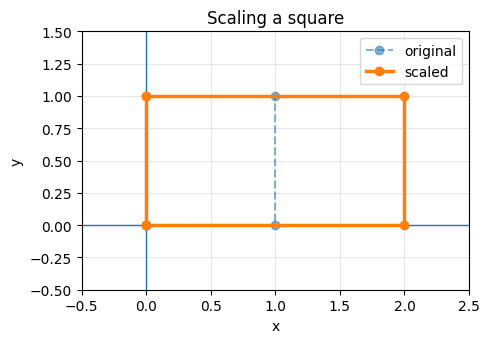

In [6]:
fig, ax = setup_shape_plot(
    "Scaling a square",
    xlim=(-0.5, 2.5),
    ylim=(-0.5, 1.5),
    figsize=(5, 4),
)

plot_shape(ax, square, label="original", linewidth=1.5, linestyle="--", alpha=0.55)
plot_shape(ax, scaled_square, label="scaled", linewidth=2.5)
ax.legend()
plt.show()

The square has become a rectangle.

The transformation was applied to every point.

## Shearing a shape

A shear slants the shape.

For this horizontal shear:

$$
H =
\begin{bmatrix}
1 & 1 \\
0 & 1
\end{bmatrix}
$$

The $y$-value contributes to the new $x$-value.

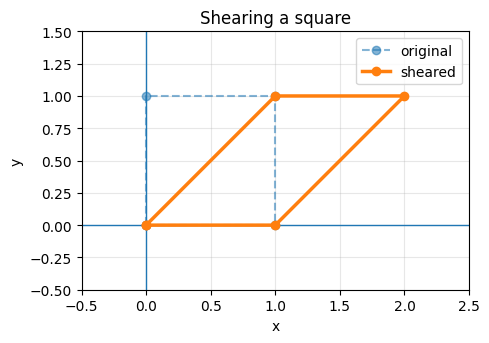

In [7]:
horizontal_shear = np.array([
    [1, 1],
    [0, 1],
])

sheared_square = transform_points(horizontal_shear, square)

fig, ax = setup_shape_plot(
    "Shearing a square",
    xlim=(-0.5, 2.5),
    ylim=(-0.5, 1.5),
    figsize=(5, 4),
)

plot_shape(ax, square, label="original", linewidth=1.5, linestyle="--", alpha=0.55)
plot_shape(ax, sheared_square, label="sheared", linewidth=2.5)
ax.legend()
plt.show()

The square becomes a slanted parallelogram.

## Rotating a shape

A rotation matrix can rotate every point in the shape.

For example, rotate the square by $45^\circ$.

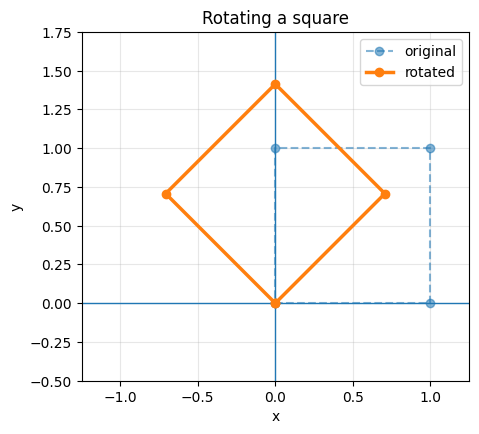

In [8]:
rotation_45 = rotation_matrix_degrees(45)
rotated_square = transform_points(rotation_45, square)

fig, ax = setup_shape_plot(
    "Rotating a square",
    xlim=(-1.25, 1.25),
    ylim=(-0.5, 1.75),
    figsize=(5, 5),
)

plot_shape(ax, square, label="original", linewidth=1.5, linestyle="--", alpha=0.55)
plot_shape(ax, rotated_square, label="rotated", linewidth=2.5)
ax.legend()
plt.show()

The square rotates around the origin because the matrix transformation is applied relative to the origin.

The point $(0, 0)$ stays fixed because every plain 2×2 matrix sends the zero vector to the zero vector.

## Why position relative to the origin matters

If a shape is not centred around the origin, rotation can make it appear to swing around the origin.

To rotate around the shape's own centre, we would usually:

1. move the shape so its centre is at the origin
2. rotate it
3. move it back

That involves translation, which is not represented by a plain 2×2 matrix in this simple setup.

## Applying several transformations

Matrix transformations can be composed.

That means we can apply one transformation, then apply another transformation to the result.

For example, we can shear the square, then rotate the already-sheared square.

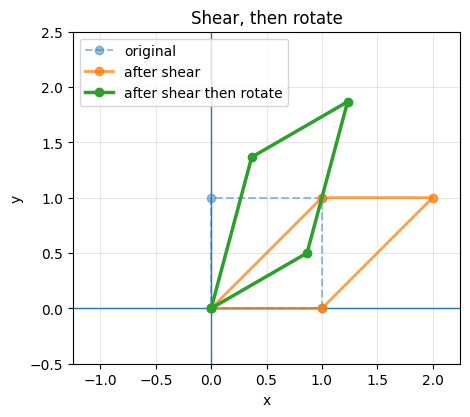

In [9]:
rotation_30 = rotation_matrix_degrees(30)
sheared_square = transform_points(horizontal_shear, square)
sheared_then_rotated = transform_points(rotation_30, sheared_square)

fig, ax = setup_shape_plot(
    "Shear, then rotate",
    xlim=(-1.25, 2.25),
    ylim=(-0.5, 2.5),
    figsize=(5, 5),
)

plot_shape(ax, square, label="original", linewidth=1.5, linestyle="--", alpha=0.45)
plot_shape(ax, sheared_square, label="after shear", linewidth=2.0, alpha=0.75)
plot_shape(ax, sheared_then_rotated, label="after shear then rotate", linewidth=2.5)

ax.legend()
plt.show()

The original square is first slanted by the shear, then the result is rotated.

## Transformation order matters

Composed matrix transformations do not generally commute.

That means applying transformation $A$ and then transformation $B$ is not usually the same as applying $B$ and then $A$.

The same transformations can produce different final shapes when the order changes.

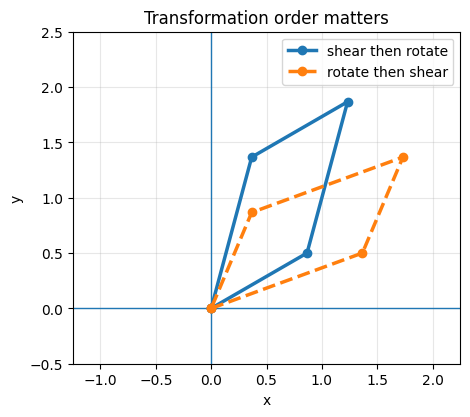

In [10]:
rotate_then_sheared = transform_points(
    horizontal_shear,
    transform_points(rotation_30, square),
)

fig, ax = setup_shape_plot(
    "Transformation order matters",
    xlim=(-1.25, 2.25),
    ylim=(-0.5, 2.5),
    figsize=(5, 5),
)

plot_shape(ax, sheared_then_rotated, label="shear then rotate", linewidth=2.5)
plot_shape(ax, rotate_then_sheared, label="rotate then shear", linewidth=2.5, linestyle="--")
ax.legend()
plt.show()

These two final shapes are different.

The same two transformations were used, but the order changed the result.

## Why this matters

Many data-processing and machine-learning operations can be viewed as transformations.

The objects may not be literal 2D shapes, but the idea is similar:

- data is represented numerically
- matrices transform that data
- transformations can be composed
- the order of transformations can matter


## Summary

A shape can be represented as a collection of points.

Each point can be treated as a position vector from the origin.

In the earlier notebooks, we transformed one vector at a time:

$$
\mathbf{v}' = A\mathbf{v}
$$

In this notebook, we applied the same idea to a whole shape.

If $P$ is the collection of points in the shape, then conceptually:

$$
P' = A(P)
$$

Read that as: apply matrix $A$ to every point in $P$.

The key takeaways are:

- transform every point, and the whole shape follows
- scaling, shear and rotation are easier to understand when applied to a visible shape
- a plain 2×2 matrix keeps the origin fixed
- rotation therefore happens around the origin
- translation needs an extra idea beyond plain 2×2 matrices
- transformations can be composed by applying one after another
- composition order matters

The main idea is:

> A matrix transformation of a shape is just the same matrix transformation applied to every point in that shape.

## Next step

Next, we will return to projections and use them as motivation for least squares.